# Data-Driven Prediction of Indoor Temperature
We train a Random Forest to predict the next-step indoor temperature from the current state and inputs.

In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import numpy as np
from predict import train_and_evaluate

# Train the model (14 days of data)
results = train_and_evaluate(n_steps=168*2)

print(f"MAE  (train): {results['MAE_train']:.3f} °C")
print(f"MAE  (test) : {results['MAE_test']:.3f} °C")
print(f"RMSE (test) : {results['RMSE_test']:.3f} °C")

MAE  (train): 0.092 °C
MAE  (test) : 0.213 °C
RMSE (test) : 0.327 °C


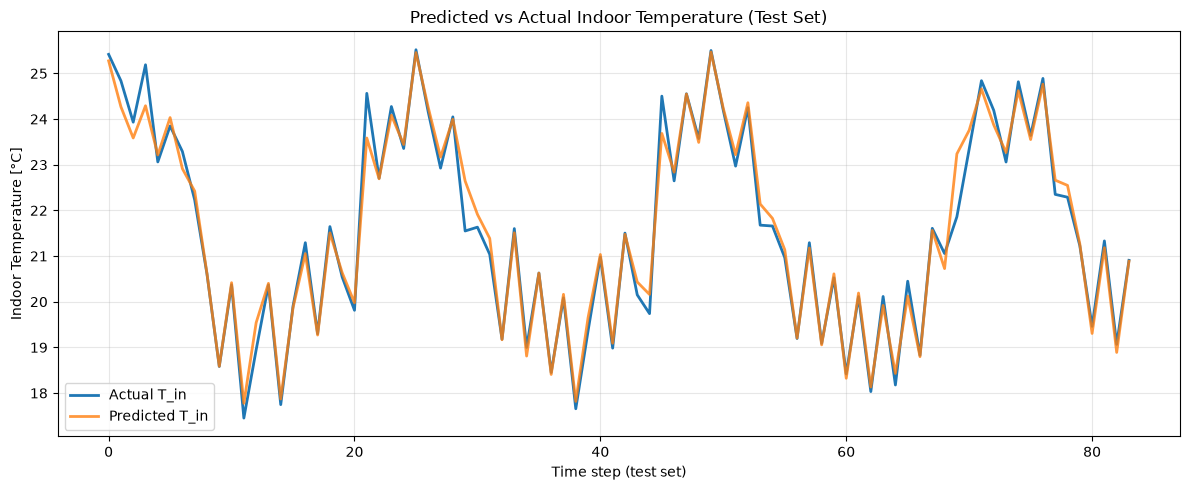

In [2]:
y_test = results["y_test"]
y_pred = results["y_pred_test"]

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual T_in", linewidth=2)
plt.plot(y_pred, label="Predicted T_in", linewidth=2, alpha=0.8)
plt.xlabel("Time step (test set)")
plt.ylabel("Indoor Temperature [°C]")
plt.title("Predicted vs Actual Indoor Temperature (Test Set)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

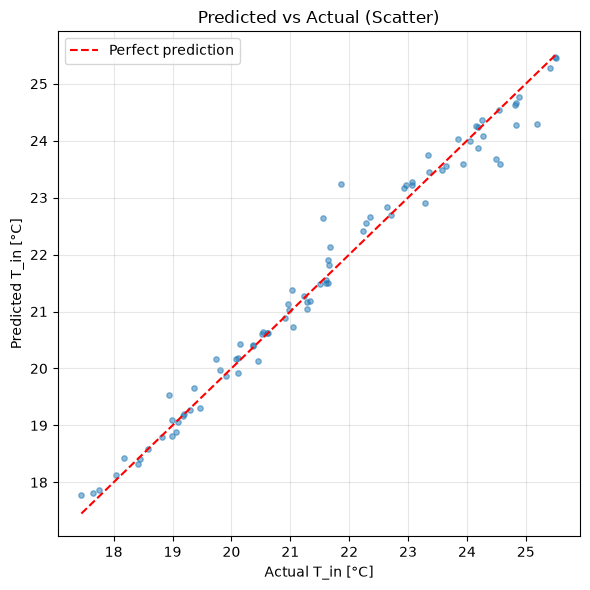

In [3]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", label="Perfect prediction")
plt.xlabel("Actual T_in [°C]")
plt.ylabel("Predicted T_in [°C]")
plt.title("Predicted vs Actual (Scatter)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

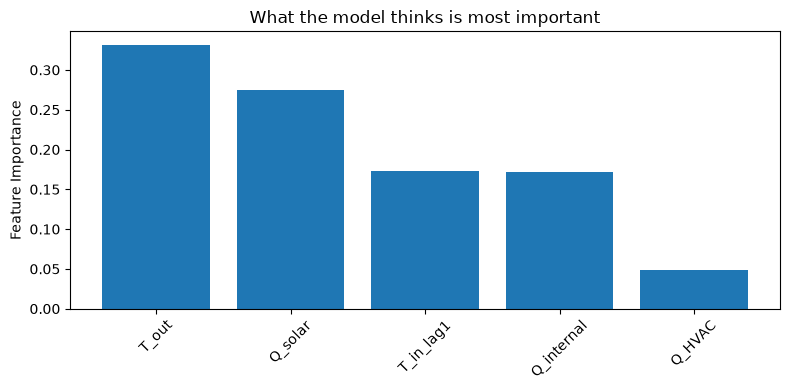

In [4]:
model = results["model"]
feature_cols = results["feature_cols"]

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar([feature_cols[i] for i in indices], importances[indices])
plt.ylabel("Feature Importance")
plt.title("What the model thinks is most important")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()